# Purposes of met data:

1. contribute to the similarity index by fetching climate attributes (mean and std)
- calculate using all available data from start to finish
2. help identify which landsat pixels should be removed based on large differences in temp
-

Fields:
* Temperature (TEMP):
  - Quality codes 1, 5, A
  - Positions 88-92
  - Units: celsius
* Humidity (DEW)
  - Quality codes 1, 5, A
  - Positions 94-98
  - Units: celsius
* Precipitation (AA)
  - AA2: millimeters
  - AA4: quality code 1, 5
* Atmospheric pressure (SLP)
  - Qualilty codes 1 and 5

Quality codes: 1,2,4,5,9
- if value is 9999, remove

#Ranges of LST and Air temp difference across seasons:
* Winter: -7 to 9 C
* Spring: 2 to 33 C
* Summer: 9 to 38 C
* Autumn: -2 to 17 C

South:
summer: Dec–Feb; autumn: Mar–May; winter: Jun–Aug; spring: Sep–Nov
North:
winter: Dec–Feb; spring: Mar–May; summer: Jun–Aug; autumn: Sep–Nov

Add 10 C on both ends to account for spatial variation

# Approach:

iterate over missions and get their times
- get the temp value at the nearest hour from met station (if none exist OR quality code is bad, move on rather than discard)
- get the max difference range

group the data df by the mission and iterate over all points (can probably vectorize df_diff as a column first)
- add all bad data to an auxiliary DF

# Imports and setup

In [1]:
import requests, warnings
import pandas as pd
import io
from google.colab import files
from time import sleep
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_origin

In [2]:
met_metadata_df = pd.read_csv(io.StringIO('''
ID,Start date,End Date,Global ID,Additional ID,ymin
1,2009,2012,72219013874,,33.75400957
3,2013,2015,72534014819,,41.91046952
4,2016,2017,76679399999,,19.43531808
5,2019,2022,76679399999,,19.43137642
6,2021,2025,72572024127,,40.74596957
7,2010,2019,47113199999,,37.61597727
8,2010,2016,47113199999,,37.5548156
9,2006,2014,74486094789,,40.7496983
10,1995,2006,07157099999,,48.91112189
11,2018,2022,72422093820,,38.03708055
12,2007,2012,72640014839,,43.03146501
13,1993,2000,72658014922,,44.94513612
14,2003,2007,83775399999,83075099999,-23.51900561
15,1988,2000,07157099999,,48.8369321
16,1991,2008,72509014739,,42.34998438
17,2015,2017,47113199999,,37.55166639
18,2004,2020,06180099999,,55.65926482
19,2010,2012,06180099999,,55.69788659
20,2012,2015,94767099999,,-33.8845652
21,2011,2013,76571099999,,21.84015311
22,2015,2016,08181099999,,41.36614561
'''), header=None)


In [3]:
met_metadata_df.columns = met_metadata_df.iloc[0]
met_metadata_df = met_metadata_df[1:]

In [4]:
met_metadata_df

,ID,Start date,End Date,Global ID,Additional ID,ymin
1,1,2009,2012,72219013874,NaN,33.75400957
2,3,2013,2015,72534014819,NaN,41.91046952
3,4,2016,2017,76679399999,NaN,19.43531808
4,5,2019,2022,76679399999,NaN,19.43137642
5,6,2021,2025,72572024127,NaN,40.74596957
6,7,2010,2019,47113199999,NaN,37.61597727
7,8,2010,2016,47113199999,NaN,37.5548156
8,9,2006,2014,74486094789,NaN,40.7496983
9,10,1995,2006,07157099999,NaN,48.91112189
10,11,2018,2022,72422093820,NaN,38.03708055


In [5]:
met_metadata_df.columns

Index(['ID', 'Start date', 'End Date', 'Global ID', 'Additional ID', 'ymin'], dtype='object', name=0)

# Validity Test 1: if station exists

In [6]:
BASE_URL = "https://www.ncei.noaa.gov/access/services/search/v1/autocomplete"

results = []

In [7]:
for station_id in met_metadata_df["Global ID"].astype(str):
    params = {
        "field": "stations",
        "dataset": "global-hourly",
        "text": station_id
    }

    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        r.raise_for_status()

        data = r.json()

        is_valid = len(data.get("results", [])) > 0

        # Grab station name if valid
        station_name = (
            data["results"][0]["name"]
            if is_valid else None
        )

        results.append({
            "station_id": station_id,
            "valid": is_valid,
            "station_name": station_name
        })

    except Exception as e:
        results.append({
            "station_id": station_id,
            "valid": False,
            "station_name": None,
            "error": str(e)
        })

    # polite pause to avoid hammering API
    sleep(0.1)

In [8]:
# Convert to DataFrame
results_df = pd.DataFrame(results)

In [9]:
results_df

,station_id,valid,station_name
0,72219013874,True,ATLANTA HARTSFIELD JACKSON INTERNATIONAL AIRPO...
1,72534014819,True,"CHICAGO MIDWAY AIRPORT, IL US"
2,76679399999,True,LICENCIADO BENITO JUAREZ INTERNATIONAL MEXICO ...
3,76679399999,True,LICENCIADO BENITO JUAREZ INTERNATIONAL MEXICO ...
4,72572024127,True,"SALT LAKE CITY INTERNATIONAL AIRPORT, UT US"
5,47113199999,True,"INCHEON INTERNATIONAL, KS"
6,47113199999,True,"INCHEON INTERNATIONAL, KS"
7,74486094789,True,"JFK INTERNATIONAL AIRPORT, NY US"
8,07157099999,True,"CHARLES DE GAULLE, FR"
9,72422093820,True,"LEXINGTON BLUEGRASS AIRPORT, KY US"


In [10]:
additional_station = "83075099999"

In [11]:
params = {
        "field": "stations",
        "dataset": "global-hourly",
        "text": additional_station
    }

r = requests.get(BASE_URL, params=params, timeout=10)
r.raise_for_status()

data = r.json()

is_valid = len(data.get("results", [])) > 0

print(is_valid)

True


# Actually pull the met data now

In [12]:
BASE_URL = "https://www.ncei.noaa.gov/access/services/data/v1"

In [13]:
met_metadata_df

,ID,Start date,End Date,Global ID,Additional ID,ymin
1,1,2009,2012,72219013874,NaN,33.75400957
2,3,2013,2015,72534014819,NaN,41.91046952
3,4,2016,2017,76679399999,NaN,19.43531808
4,5,2019,2022,76679399999,NaN,19.43137642
5,6,2021,2025,72572024127,NaN,40.74596957
6,7,2010,2019,47113199999,NaN,37.61597727
7,8,2010,2016,47113199999,NaN,37.5548156
8,9,2006,2014,74486094789,NaN,40.7496983
9,10,1995,2006,07157099999,NaN,48.91112189
10,11,2018,2022,72422093820,NaN,38.03708055


In [14]:
met_metadata_df.columns

Index(['ID', 'Start date', 'End Date', 'Global ID', 'Additional ID', 'ymin'], dtype='object', name=0)

In [15]:
# Create output directory
output_dir = Path("met_csvs")
output_dir.mkdir(exist_ok=True)

In [16]:
current_year = datetime.now().year

In [17]:
columns = ['ID', 'TMP_mean', 'TMP_std', 'DEW_mean', 'DEW_std', 'AA_mean', 'AA_std', 'SLP_mean', 'SLP_std']
similarity_results_df = pd.DataFrame(columns=columns)

In [18]:
similarity_results_df

,ID,TMP_mean,TMP_std,DEW_mean,DEW_std,AA_mean,AA_std,SLP_mean,SLP_std


In [19]:
def get_mean_std(df, value_col, qc_col, good_qc):
    mask = (
        df[value_col].notna() &
        (df[value_col] != 9999) &
        (df[qc_col].isin(good_qc))
    )

    mean = df.loc[mask, value_col].mean()
    std = df.loc[mask, value_col].std()

    return mean, std

In [20]:
def process_raw_df(use_df):
    use_df = use_df.drop(columns=['STATION', 'SOURCE', 'REPORT_TYPE', "CALL_SIGN", "QUALITY_CONTROL", "DATE.1"])

    # Process TMP
    use_df[['TMP_value', 'TMP_quality']] = use_df['TMP'].str.split(',', expand=True)
    use_df = use_df.drop(columns=['TMP'])
    use_df["TMP_value"] = pd.to_numeric(
        use_df["TMP_value"].str.replace("+", "", regex=False)
    )
    use_df["TMP_value"] = use_df["TMP_value"] / 10

    value_col = "TMP_value"
    qc_col = "TMP_quality"
    good_qc = ["1", "5", "A"]
    tmp_mean, tmp_std = get_mean_std(use_df, value_col, qc_col, good_qc)


    # Process DEW
    use_df[['DEW_value', 'DEW_quality']] = use_df['DEW'].str.split(',', expand=True)
    use_df = use_df.drop(columns=['DEW'])
    use_df["DEW_value"] = pd.to_numeric(
        use_df["DEW_value"].str.replace("+", "", regex=False)
    )
    use_df["DEW_value"] = use_df["DEW_value"] / 10

    value_col = "DEW_value"
    qc_col = "DEW_quality"
    good_qc = ["1", "5", "A"]
    dew_mean, dew_std = get_mean_std(use_df, value_col, qc_col, good_qc)


    # Process AA
    if (use_df['AA1'].isna().all()):
        aa_mean, aa_std = None, None
    else:
        use_df[['A1', 'A2', 'A3', 'A4']] = use_df['AA1'].str.split(',', expand=True)
        use_df = use_df.drop(columns=['AA1'])
        use_df['A2'] = pd.to_numeric(use_df['A2'])

        value_col = "A2"
        qc_col = "A4"
        good_qc = ["1", "5"]
        aa_mean, aa_std = get_mean_std(use_df, value_col, qc_col, good_qc)


    # Process SLP
    use_df[['SLP_value', 'SLP_quality']] = use_df['SLP'].str.split(',', expand=True)

    use_df = use_df.drop(columns=['SLP'])
    use_df['SLP_value'] = pd.to_numeric(use_df['SLP_value'])

    value_col = "SLP_value"
    qc_col = "SLP_quality"
    good_qc = ["1", "5"]
    slp_mean, slp_std = get_mean_std(use_df, value_col, qc_col, good_qc)


    row_data = [tmp_mean, tmp_std, dew_mean, dew_std, aa_mean, aa_std, slp_mean, slp_std]

    return use_df, row_data

In [21]:
manual_df = None

In [22]:
for _, row in met_metadata_df.iterrows():

    # -----------------------------
    # Extract row values
    # -----------------------------
    id_value = str(row["ID"]).strip()

    if (id_value == "14"):
        continue

    station = str(row["Global ID"]).strip()

    # Convert years from string -> int
    start_year = int(float(row["Start date"]))
    end_year = int(float(row["End Date"]))

    # Expand by +/- 5 years
    request_start = start_year
    request_end = min(end_year, current_year)

    print(f"\nFetching station {station} for ID {id_value}")
    print(f"Date range: {request_start} -> {request_end}")

    params = {
        "dataset": "global-hourly",
        "format": "csv",
        "units": "metric",
        "stations": station,
        "startDate": f"{request_start}-01-01",
        "endDate": f"{request_end}-12-31",
        "dataTypes": (
            "DATE,TMP,DEW,SLP,AA1"
        ),
    }

    try:
        r = requests.get(BASE_URL, params=params, timeout=120)

        # Raise HTTP errors
        r.raise_for_status()

        # NOAA sometimes returns empty response
        if not r.text.strip():
            warnings.warn(f"No data returned for station: {station}")

            continue

        # Read CSV into DataFrame
        df = pd.read_csv(
            io.StringIO(r.text),
            dtype=str,
            low_memory=False
        )

        manual_df = df

        # Handle accidental empty CSV
        if df.empty:
            warnings.warn(f"Empty dataframe for station: {station}")

            continue
        else:
            df, results = process_raw_df(df)
            similarity_results_df.loc[int(id_value)] = [id_value, *results]

        # Prepare only TMP to export
        mask = (
            df['TMP_value'].notna() &
            (df['TMP_value'] != 9999) &
            (df['TMP_quality'].isin(["1", "5", "A"]))
        )

        df = df[mask]
        df = df[['DATE', 'TMP_value']]

        # -----------------------------------------
        # Save CSV
        # -----------------------------------------
        output_path = output_dir / f"{id_value}_met.csv"

        df.to_csv(output_path, index=False)

        print(f"Saved: {output_path}")
        print(f"Rows: {len(df)}")

    except Exception as e:

        print(f"FAILED for ID {id_value}: {e}")

    # Be polite to NOAA
    sleep(0.2)


Fetching station 72219013874 for ID 1
Date range: 2009 -> 2012
Saved: met_csvs/1_met.csv
Rows: 49091

Fetching station 72534014819 for ID 3
Date range: 2013 -> 2015
Saved: met_csvs/3_met.csv
Rows: 36532

Fetching station 76679399999 for ID 4
Date range: 2016 -> 2017
Saved: met_csvs/4_met.csv
Rows: 23202

Fetching station 76679399999 for ID 5
Date range: 2019 -> 2022
Saved: met_csvs/5_met.csv
Rows: 43823

Fetching station 72572024127 for ID 6
Date range: 2021 -> 2025
Saved: met_csvs/6_met.csv
Rows: 59074

Fetching station 47113199999 for ID 7
Date range: 2010 -> 2019


/tmp/ipykernel_1471/3182862840.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  similarity_results_df.loc[int(id_value)] = [id_value, *results]


Saved: met_csvs/7_met.csv
Rows: 174900

Fetching station 47113199999 for ID 8
Date range: 2010 -> 2016


/tmp/ipykernel_1471/3182862840.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  similarity_results_df.loc[int(id_value)] = [id_value, *results]


Saved: met_csvs/8_met.csv
Rows: 122481

Fetching station 74486094789 for ID 9
Date range: 2006 -> 2014
Saved: met_csvs/9_met.csv
Rows: 117261

Fetching station 07157099999 for ID 10
Date range: 1995 -> 2006
Saved: met_csvs/10_met.csv
Rows: 153568

Fetching station 72422093820 for ID 11
Date range: 2018 -> 2022
Saved: met_csvs/11_met.csv
Rows: 66086

Fetching station 72640014839 for ID 12
Date range: 2007 -> 2012
Saved: met_csvs/12_met.csv
Rows: 75388

Fetching station 72658014922 for ID 13
Date range: 1993 -> 2000
Saved: met_csvs/13_met.csv
Rows: 79933

Fetching station 07157099999 for ID 15
Date range: 1988 -> 2000
Saved: met_csvs/15_met.csv
Rows: 159206

Fetching station 72509014739 for ID 16
Date range: 1991 -> 2008
Saved: met_csvs/16_met.csv
Rows: 198591

Fetching station 47113199999 for ID 17
Date range: 2015 -> 2017


/tmp/ipykernel_1471/3182862840.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  similarity_results_df.loc[int(id_value)] = [id_value, *results]


Saved: met_csvs/17_met.csv
Rows: 52526

Fetching station 06180099999 for ID 18
Date range: 2004 -> 2020
Saved: met_csvs/18_met.csv
Rows: 438994

Fetching station 06180099999 for ID 19
Date range: 2010 -> 2012
Saved: met_csvs/19_met.csv
Rows: 78117

Fetching station 94767099999 for ID 20
Date range: 2012 -> 2015
Saved: met_csvs/20_met.csv
Rows: 97888

Fetching station 76571099999 for ID 21
Date range: 2011 -> 2013
Saved: met_csvs/21_met.csv
Rows: 25940

Fetching station 08181099999 for ID 22
Date range: 2015 -> 2016
Saved: met_csvs/22_met.csv
Rows: 52334


In [23]:
similarity_results_df

,ID,TMP_mean,TMP_std,DEW_mean,DEW_std,AA_mean,AA_std,SLP_mean,SLP_std
1,1,17.151162,8.895042,10.580663,9.067887,5.241838,29.522233,10173.320032,56.197743
3,3,10.247671,11.820853,4.079348,11.214462,3.248412,21.388688,10171.519865,78.374431
4,4,17.439660,4.712355,6.048428,5.410814,13.594027,23.997739,10100.206573,43.202409
5,5,18.152819,4.610861,6.283146,5.164819,13.408092,25.835847,10097.517034,39.900865
6,6,12.837741,11.617727,0.726982,5.992759,1.574613,9.579034,10148.359924,80.543105
7,7,12.283516,10.624608,5.360616,11.603106,NaN,NaN,NaN,NaN
8,8,12.139956,10.630761,5.509210,11.603910,NaN,NaN,NaN,NaN
9,9,12.795965,9.309149,5.957946,10.514961,4.778626,27.153400,10164.086869,79.599746
10,10,11.775124,7.275940,7.166305,5.681887,1.917149,10.260139,10166.886749,90.212809
11,11,13.401963,10.099326,8.228121,9.968018,5.871665,27.665798,10180.468058,64.099131


## Manually handle id 14

In [24]:
params = {
    "dataset": "global-hourly",
    "format": "csv",
    "units": "metric",
    "stations": "83775399999",
    "startDate": "2003-01-01",
    "endDate": f"2004-12-31",
    "dataTypes": (
        "DATE,TMP,DEW,SLP,AA1"
    ),
}

try:
    r = requests.get(BASE_URL, params=params, timeout=120)

    # Raise HTTP errors
    r.raise_for_status()

    # NOAA sometimes returns empty response
    if not r.text.strip():
        warnings.warn(f"No data returned for station: {station}")

    # Read CSV into DataFrame
    df_1 = pd.read_csv(
        io.StringIO(r.text),
        dtype=str,
        low_memory=False
    )
except Exception as e:
    print(f"{e}")

In [25]:
params = {
    "dataset": "global-hourly",
    "format": "csv",
    "units": "metric",
    "stations": "83075099999",
    "startDate": "2003-01-01",
    "endDate": f"2007-12-31",
    "dataTypes": (
        "DATE,TMP,DEW,SLP,AA1"
    ),
}

try:
    r = requests.get(BASE_URL, params=params, timeout=120)

    # Raise HTTP errors
    r.raise_for_status()

    # NOAA sometimes returns empty response
    if not r.text.strip():
        warnings.warn(f"No data returned for station: {station}")

    # Read CSV into DataFrame
    df_2 = pd.read_csv(
        io.StringIO(r.text),
        dtype=str,
        low_memory=False
    )
except Exception as e:
    print(f"{e}")

In [26]:
df_index_14 = pd.concat([df_1, df_2], axis=0, ignore_index=True)

In [27]:
df, results = process_raw_df(df_index_14)

In [28]:
similarity_results_df.loc[14] = ["14", *results]

/tmp/ipykernel_1471/1887038357.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  similarity_results_df.loc[14] = ["14", *results]


In [29]:
similarity_results_df

,ID,TMP_mean,TMP_std,DEW_mean,DEW_std,AA_mean,AA_std,SLP_mean,SLP_std
1,1,17.151162,8.895042,10.580663,9.067887,5.241838,29.522233,10173.320032,56.197743
3,3,10.247671,11.820853,4.079348,11.214462,3.248412,21.388688,10171.519865,78.374431
4,4,17.439660,4.712355,6.048428,5.410814,13.594027,23.997739,10100.206573,43.202409
5,5,18.152819,4.610861,6.283146,5.164819,13.408092,25.835847,10097.517034,39.900865
6,6,12.837741,11.617727,0.726982,5.992759,1.574613,9.579034,10148.359924,80.543105
7,7,12.283516,10.624608,5.360616,11.603106,NaN,NaN,NaN,NaN
8,8,12.139956,10.630761,5.509210,11.603910,NaN,NaN,NaN,NaN
9,9,12.795965,9.309149,5.957946,10.514961,4.778626,27.153400,10164.086869,79.599746
10,10,11.775124,7.275940,7.166305,5.681887,1.917149,10.260139,10166.886749,90.212809
11,11,13.401963,10.099326,8.228121,9.968018,5.871665,27.665798,10180.468058,64.099131


In [30]:
test_df = similarity_results_df.sort_index()

In [31]:
test_df.to_csv('similarity_results.csv', index=False)

In [32]:
# Prepare only TMP to export
mask = (
    df['TMP_value'].notna() &
    (df['TMP_value'] != 9999) &
    (df['TMP_quality'].isin(["1", "5", "A"]))
)

df = df[mask]
df = df[['DATE', 'TMP_value']]

# -----------------------------------------
# Save CSV
# -----------------------------------------
output_path = output_dir / f"14_met.csv"

df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Rows: {len(df)}")

Saved: met_csvs/14_met.csv
Rows: 46651


# Identify suspect Landsat pixels

In [33]:
met_metadata_df

,ID,Start date,End Date,Global ID,Additional ID,ymin
1,1,2009,2012,72219013874,NaN,33.75400957
2,3,2013,2015,72534014819,NaN,41.91046952
3,4,2016,2017,76679399999,NaN,19.43531808
4,5,2019,2022,76679399999,NaN,19.43137642
5,6,2021,2025,72572024127,NaN,40.74596957
6,7,2010,2019,47113199999,NaN,37.61597727
7,8,2010,2016,47113199999,NaN,37.5548156
8,9,2006,2014,74486094789,NaN,40.7496983
9,10,1995,2006,07157099999,NaN,48.91112189
10,11,2018,2022,72422093820,NaN,38.03708055


## Ranges of LST and Air temp difference across seasons:
* Winter: -7 to 9 C
* Spring: 2 to 33 C
* Summer: 9 to 38 C
* Autumn: -2 to 17 C

South:
summer: Dec–Feb; autumn: Mar–May; winter: Jun–Aug; spring: Sep–Nov
North:
winter: Dec–Feb; spring: Mar–May; summer: Jun–Aug; autumn: Sep–Nov

Add 10 C on both ends to account for spatial variation

In [34]:
columns = ['case_id', 'fid', 'mission_id', 'LST_K', 'MET_K', 'diff_allowed']
bad_data_df = pd.DataFrame(columns=columns)

In [35]:
bad_data_df

,case_id,fid,mission_id,LST_K,MET_K,diff_allowed


In [36]:
processed_data_dfs = {}

In [37]:
for _, row in met_metadata_df.iterrows():

    # -----------------------------
    # Extract row values
    # -----------------------------
    id_value = str(row["ID"]).strip()
    is_north = (float(row["ymin"]) > 0)

    data_url = "https://raw.githubusercontent.com/thomaslu678/Praxis-Lab-25-26/refs/heads/main/assets/Raw%20Landsat/" + id_value + "_data.csv"
    metadata_url = "https://raw.githubusercontent.com/thomaslu678/Praxis-Lab-25-26/refs/heads/main/assets/Raw%20Landsat/" + id_value + "_metadata.csv"
    points_url = "https://raw.githubusercontent.com/thomaslu678/Praxis-Lab-25-26/refs/heads/main/assets/QGIS%20Outputs/" + id_value + "/points.csv"

    data_df = pd.read_csv(data_url)
    metadata_df = pd.read_csv(metadata_url)
    points_df = pd.read_csv(points_url)

    metadata_df['time'] = pd.to_datetime(metadata_df['time'])

    met_df = pd.read_csv("/content/met_csvs/" + id_value + "_met.csv")
    met_df['TMP_value'] = met_df['TMP_value'] + 273.15
    met_df['DATE'] = pd.to_datetime(met_df['DATE'])

    # Get the closest met observation per metadata row and add MET_K value
    metadata_df = pd.merge_asof(
        metadata_df.sort_values("time"),
        met_df[["DATE", "TMP_value"]].sort_values("DATE"),
        left_on="time",
        right_on="DATE",
        direction="nearest"
    )
    metadata_df = metadata_df.rename(columns={"TMP_value": "MET_K"})

    # Pull MET_K from metadata_df
    data_df["MET_K"] = data_df["mission_id"].map(
        metadata_df.set_index("mission_id")["MET_K"]
    )

    # Calculate diff_K
    data_df['DIFF_K'] = data_df['LST_K'] - data_df['MET_K']

    processed_data_dfs[id_value] = {}
    processed_data_dfs[id_value]['data'] = data_df
    processed_data_dfs[id_value]['metadata'] = metadata_df
    processed_data_dfs[id_value]['points'] = points_df


    # do entire workflow

    # Only need mission_id and time for this step
    mission_times = (
        metadata_df[["mission_id", "time"]]
        .drop_duplicates("mission_id")
    )

    data_check = data_df.merge(
        mission_times,
        on="mission_id",
        how="left"
    )

    # Make sure time is datetime
    data_check["time"] = pd.to_datetime(data_check["time"])

    # Get month
    data_check["month"] = data_check["time"].dt.month


    # ---------------------------------------------------------
    # 2. Determine season based on hemisphere
    # ---------------------------------------------------------

    if is_north:
        season_map = {
            12: "Winter", 1: "Winter", 2: "Winter",
            3: "Spring", 4: "Spring", 5: "Spring",
            6: "Summer", 7: "Summer", 8: "Summer",
            9: "Autumn", 10: "Autumn", 11: "Autumn"
        }
    else:
        season_map = {
            12: "Summer", 1: "Summer", 2: "Summer",
            3: "Autumn", 4: "Autumn", 5: "Autumn",
            6: "Winter", 7: "Winter", 8: "Winter",
            9: "Spring", 10: "Spring", 11: "Spring"
        }

    data_check["season"] = data_check["month"].map(season_map)


    # ---------------------------------------------------------
    # 3. Define allowed DIFF_K thresholds
    # ---------------------------------------------------------

    thresholds = {
        "Winter": (-7, 9),
        "Spring": (2, 33),
        "Summer": (9, 38),
        "Autumn": (-2, 17)
    }

    data_check["lower_threshold"] = data_check["season"].map(
        lambda x: thresholds[x][0] - 10
    )

    data_check["upper_threshold"] = data_check["season"].map(
        lambda x: thresholds[x][1] + 10
    )


    # ---------------------------------------------------------
    # 4. Find bad data
    # ---------------------------------------------------------

    bad_mask = (
        (data_check["DIFF_K"] < data_check["lower_threshold"]) |
        (data_check["DIFF_K"] > data_check["upper_threshold"])
    )

    bad_rows = data_check.loc[bad_mask].copy()


    # ---------------------------------------------------------
    # 5. Calculate diff_allowed
    # ---------------------------------------------------------

    # If below the allowed range:
    #     DIFF_K - lower_threshold
    #
    # If above the allowed range:
    #     DIFF_K - upper_threshold
    #
    # This preserves the sign, as requested.

    bad_rows["diff_allowed"] = bad_rows["DIFF_K"].where(
        bad_rows["DIFF_K"] < bad_rows["lower_threshold"],
        bad_rows["DIFF_K"] - bad_rows["upper_threshold"]
    )

    # The above needs the lower-threshold calculation explicitly
    # for values below the lower bound:
    bad_rows.loc[
        bad_rows["DIFF_K"] < bad_rows["lower_threshold"],
        "diff_allowed"
    ] = (
        bad_rows["DIFF_K"] -
        bad_rows["lower_threshold"]
    )


    # ---------------------------------------------------------
    # 6. Build rows for bad_data_df
    # ---------------------------------------------------------

    new_bad_data = bad_rows[
        ["fid", "mission_id", "LST_K", "MET_K", "diff_allowed"]
    ].copy()

    new_bad_data.insert(0, "case_id", id_value)


    # ---------------------------------------------------------
    # 7. Append to bad_data_df
    # ---------------------------------------------------------

    bad_data_df = pd.concat(
        [bad_data_df, new_bad_data],
        ignore_index=True
    )

    print("Handled case " + id_value)

/tmp/ipykernel_1471/4244648510.py:165: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bad_data_df = pd.concat(


Handled case 1
Handled case 3
Handled case 4
Handled case 5
Handled case 6
Handled case 7
Handled case 8
Handled case 9
Handled case 10
Handled case 11
Handled case 12
Handled case 13
Handled case 14
Handled case 15
Handled case 16
Handled case 17
Handled case 18
Handled case 19
Handled case 20
Handled case 21
Handled case 22


In [38]:
bad_data_df[bad_data_df['diff_allowed'] < -50]

,case_id,fid,mission_id,LST_K,MET_K,diff_allowed
18863,7,212,LT05_116034_20100316,215.200211,276.15,-52.949789
18864,7,213,LT05_116034_20100316,215.200211,276.15,-52.949789
18865,7,214,LT05_116034_20100316,200.830855,276.15,-67.319145
18866,7,215,LT05_116034_20100316,199.121845,276.15,-69.028155
18867,7,216,LT05_116034_20100316,199.121845,276.15,-69.028155
...,...,...,...,...,...,...
23621,8,1336,LT05_116034_20100316,199.231222,276.15,-68.918778
23622,8,1337,LT05_116034_20100316,204.248875,276.15,-63.901125
23623,8,1338,LT05_116034_20100316,216.700722,276.15,-51.449278
25840,11,232,LE07_019034_20180829,243.614212,302.55,-57.935788


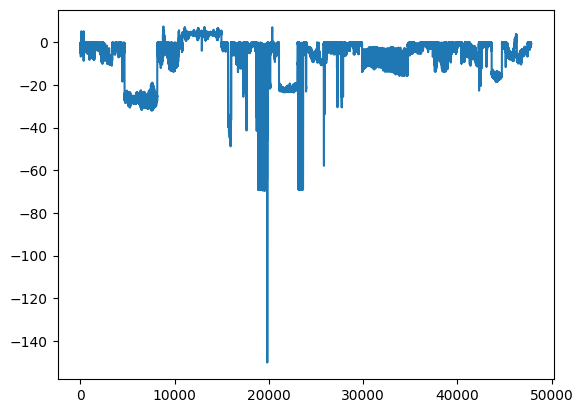

In [39]:
plt.plot(bad_data_df['diff_allowed'])

In [40]:
bad_data_df

,case_id,fid,mission_id,LST_K,MET_K,diff_allowed
0,1,1803,LT05_019037_20100612,301.580413,303.15,-0.569587
1,1,1804,LT05_019037_20100612,301.580413,303.15,-0.569587
2,1,2197,LT05_019037_20100612,301.857272,303.15,-0.292728
3,1,2223,LT05_019037_20100612,301.799166,303.15,-0.350834
4,1,2274,LT05_019037_20100612,301.806002,303.15,-0.343998
...,...,...,...,...,...,...
47813,22,1082,LE07_197031_20150329,280.299820,289.15,-0.850180
47814,22,1083,LE07_197031_20150329,280.299820,289.15,-0.850180
47815,22,1084,LE07_197031_20150329,280.299820,289.15,-0.850180
47816,22,1085,LE07_197031_20150329,280.412615,289.15,-0.737385


In [41]:
# bad_data_df.to_csv('bad_data.csv', index=False)

In [42]:
processed_data_dfs['1']['points']

,fid,row_index,col_index,distance,x,y
0,0,0,19,347.376974,-84.366623,33.754827
1,1,0,20,335.821405,-84.366299,33.754820
2,2,0,21,326.620987,-84.365976,33.754813
3,3,0,22,319.978942,-84.365652,33.754806
4,4,0,23,316.056604,-84.365329,33.754799
...,...,...,...,...,...,...
2973,2973,112,10,328.821797,-84.368609,33.785162
2974,2974,112,11,327.941974,-84.368286,33.785155
2975,2975,112,12,329.800096,-84.367962,33.785148
2976,2976,112,13,334.350516,-84.367638,33.785141


In [43]:
for key, dfs in processed_data_dfs.items():
    data_df = dfs["data"]
    metadata_df = dfs["metadata"]
    points_df = dfs["points"]

    # ---------------------------------------------------------
    # 1. Get observation time for each row in data_df
    # ---------------------------------------------------------
    mission_to_time = metadata_df.set_index("mission_id")["time"]

    data_df = data_df.copy()
    data_df["time"] = data_df["mission_id"].map(mission_to_time)

    # ---------------------------------------------------------
    # 2. Get invalid (fid, mission_id) combinations for this case
    # ---------------------------------------------------------
    # case_id in bad_data_df corresponds to the key in
    # processed_data_dfs, so make sure the types match.
    bad_for_case = bad_data_df[
        bad_data_df["case_id"].astype(str) == str(key)
    ]

    invalid_pairs = set(
        zip(
            bad_for_case["fid"],
            bad_for_case["mission_id"]
        )
    )

    # Create a mask identifying rows that are NOT invalid
    valid_mask = ~data_df.set_index(
        ["fid", "mission_id"]
    ).index.isin(invalid_pairs)

    # Keep only valid observations
    data_valid = data_df.loc[valid_mask].copy()

    # ---------------------------------------------------------
    # 3. Fit harmonic regression independently for each fid
    # ---------------------------------------------------------
    slopes = {}

    for fid, group in data_valid.groupby("fid"):
        group = group.sort_values("time").dropna(
            subset=["time", "DIFF_K"]
        )

        # Need at least 4 observations for:
        # intercept + slope + sine + cosine
        if len(group) < 4:
            slopes[fid] = np.nan
            continue

        # Time in years, relative to first valid observation
        t = (
            group["time"] - group["time"].min()
        ).dt.total_seconds() / (365.25 * 24 * 3600)

        t = t.to_numpy()
        y = group["DIFF_K"].to_numpy()

        # Annual harmonic
        omega = 2 * np.pi

        X = np.column_stack([
            np.ones(len(t)),            # intercept
            t,                          # linear trend
            np.sin(omega * t),          # seasonal sine
            np.cos(omega * t),          # seasonal cosine
        ])

        coefficients, *_ = np.linalg.lstsq(X, y, rcond=None)

        # Linear trend / slope
        slopes[fid] = coefficients[1]

    # ---------------------------------------------------------
    # 4. Add slopes to points_df
    # ---------------------------------------------------------
    points_df = points_df.copy()
    points_df["slope"] = points_df["fid"].map(slopes)

    processed_data_dfs[key]["points"] = points_df

    print("Handled case " + key)

Handled case 1
Handled case 3
Handled case 4
Handled case 5
Handled case 6
Handled case 7
Handled case 8
Handled case 9
Handled case 10
Handled case 11
Handled case 12
Handled case 13
Handled case 14
Handled case 15
Handled case 16
Handled case 17
Handled case 18
Handled case 19
Handled case 20
Handled case 21
Handled case 22


In [49]:
processed_data_dfs.keys()

dict_keys(['1', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22'])

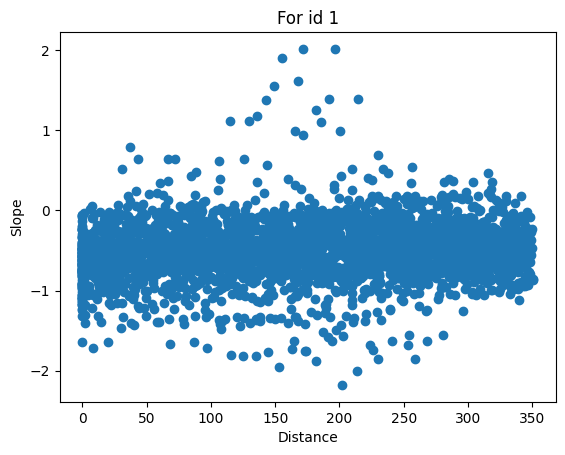

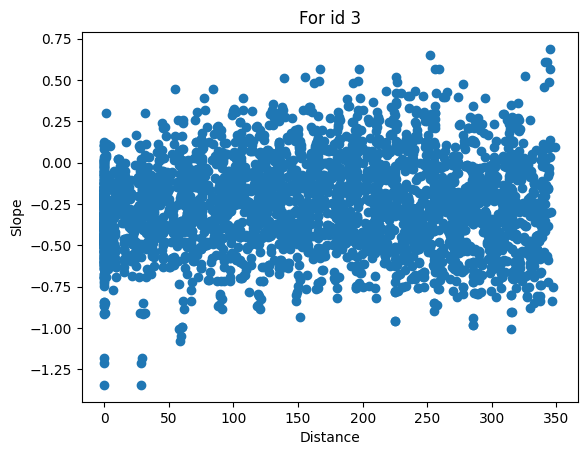

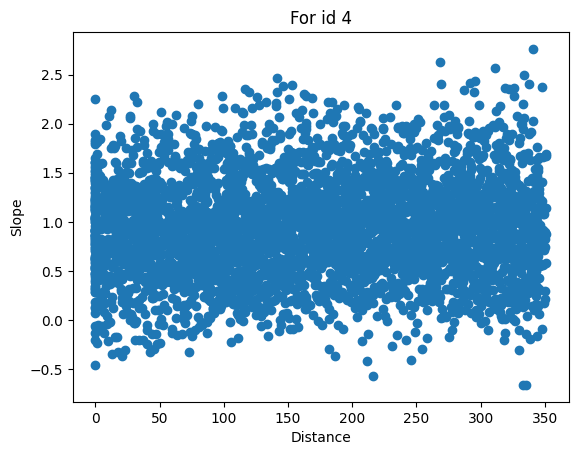

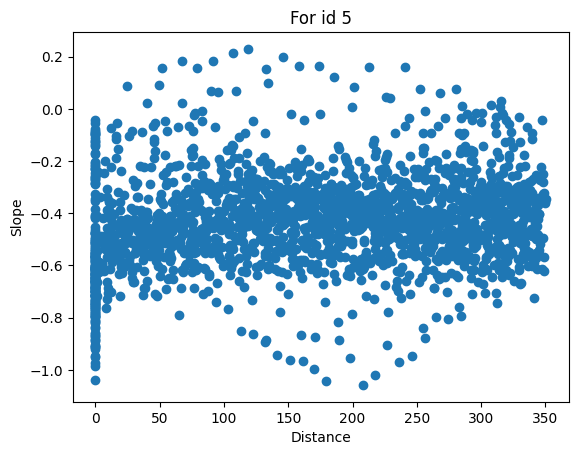

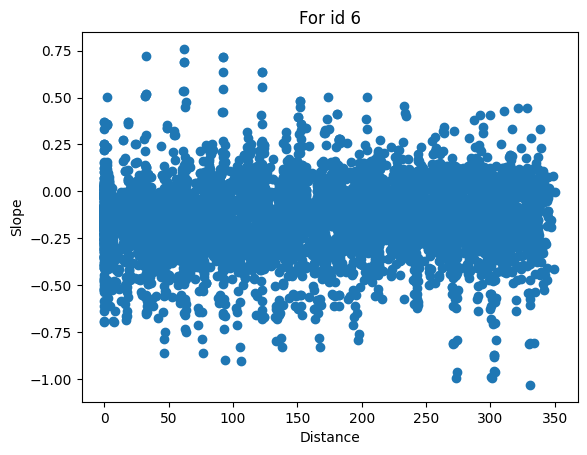

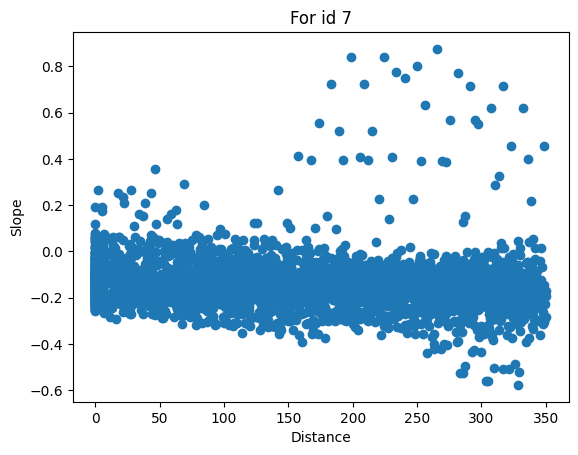

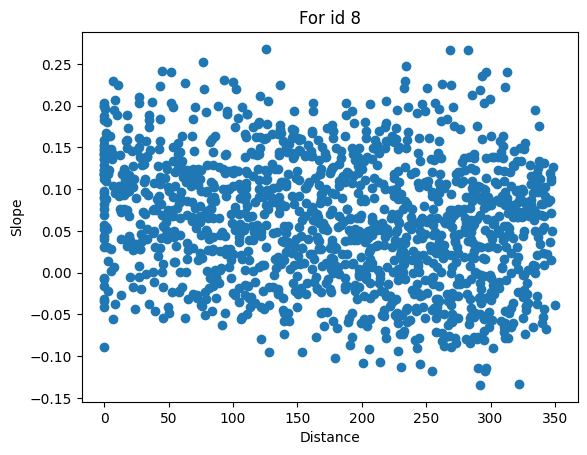

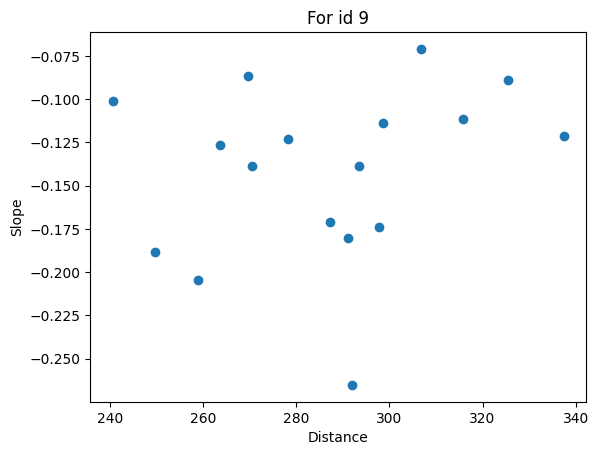

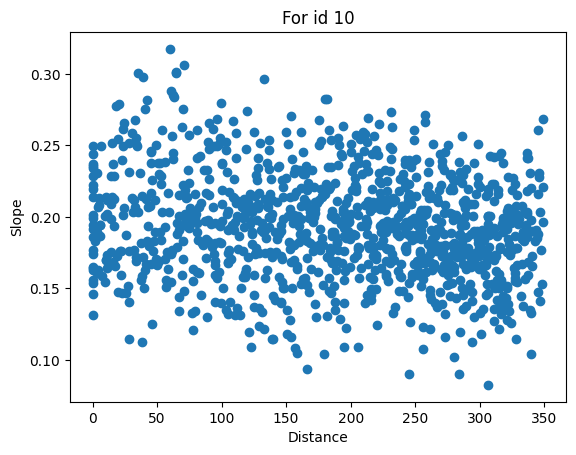

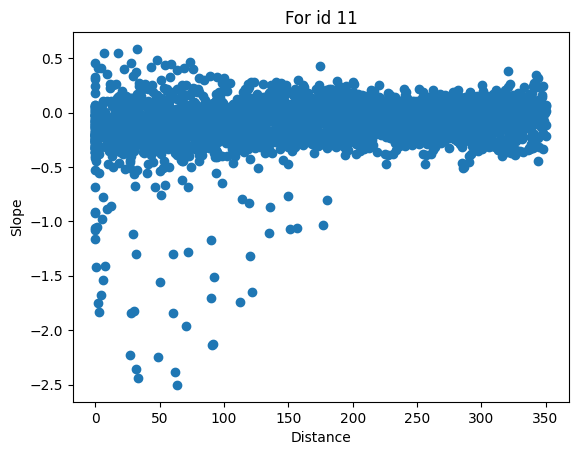

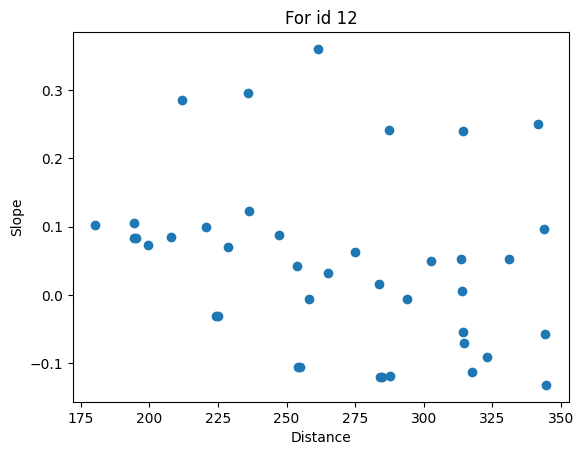

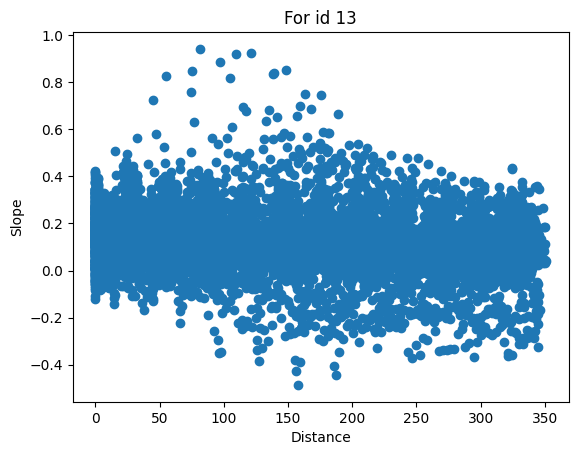

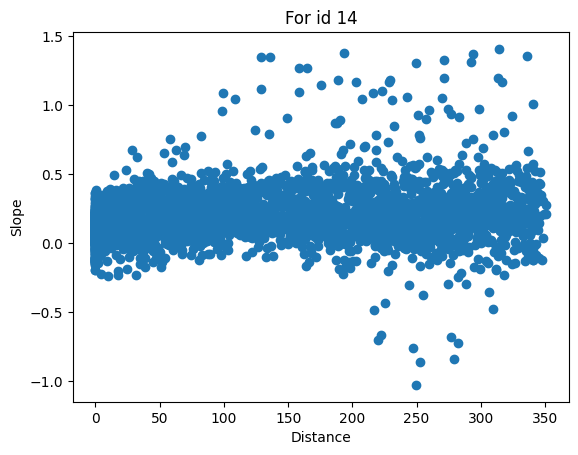

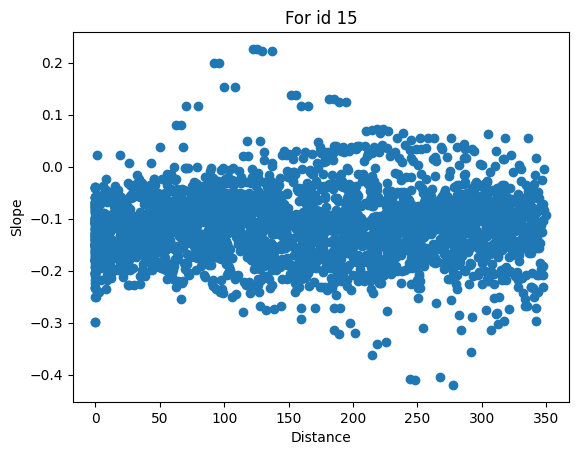

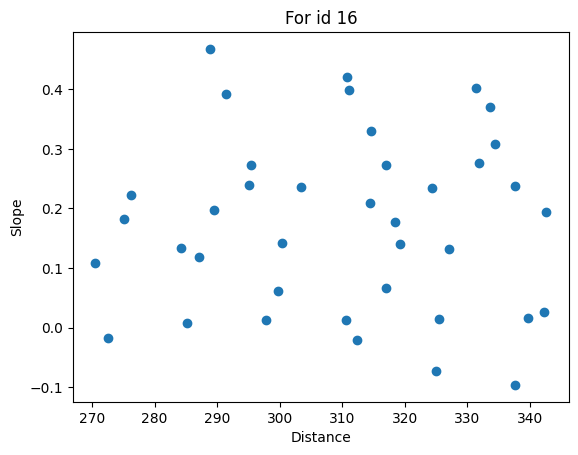

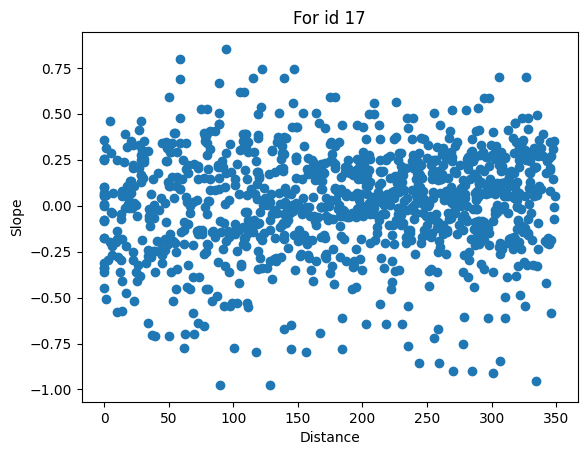

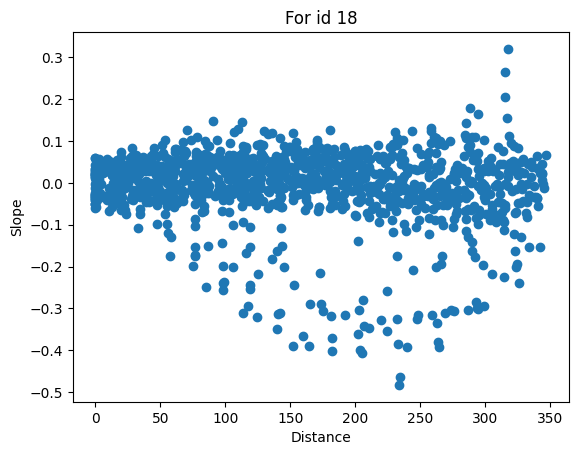

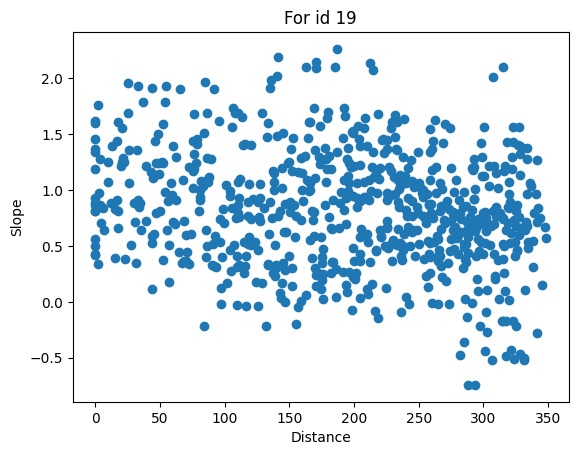

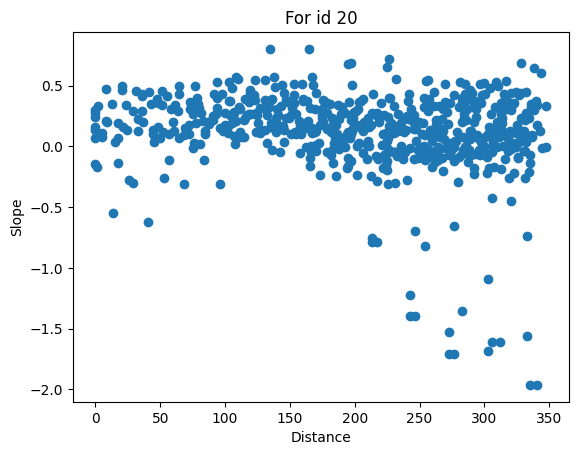

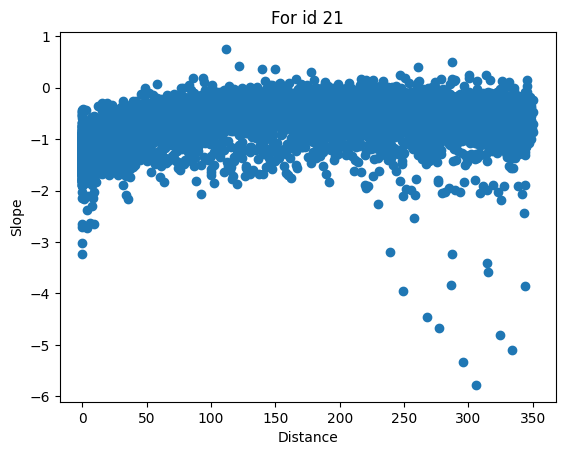

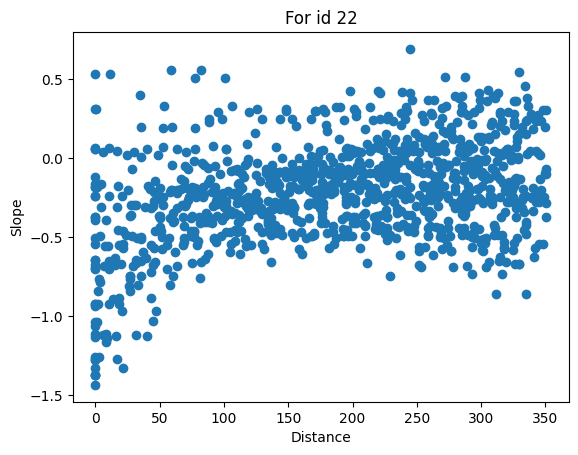

In [50]:
for id in processed_data_dfs.keys():
    plt.title("For id " + id)
    plt.xlabel("Distance")
    plt.ylabel("Slope")

    plt.scatter(processed_data_dfs[id]['points']['distance'], processed_data_dfs[id]['points']['slope'])
    plt.show()

## Just download points for id 1 for now

In [62]:
epsg_url = "https://raw.githubusercontent.com/thomaslu678/Praxis-Lab-25-26/refs/heads/main/assets/studies/Case%20ID%20%2B%20EPSG.csv"
case_id_epsgs = pd.read_csv(epsg_url)

In [77]:
def generate_tif(id):
    # id should be in string format
    df = processed_data_dfs[id]['points']

    # Make sure indices are integers
    df["row_index"] = df["row_index"].astype(int)
    df["col_index"] = df["col_index"].astype(int)

    # --------------------------------------------------
    # 2. Define CRS
    # --------------------------------------------------

    source_crs = "EPSG:4326"    # x/y in your CSV = lon/lat
    target_crs = "EPSG:" + str(case_id_epsgs.iloc[int(id)]['EPSG'])  # example: UTM Zone 16N

    # --------------------------------------------------
    # 3. Number of raster rows/columns
    # --------------------------------------------------

    nrows = df["row_index"].max() + 1
    ncols = df["col_index"].max() + 1

    print("Raster dimensions:")
    print("Rows:", nrows)
    print("Columns:", ncols)

    # --------------------------------------------------
    # 4. Create raster array
    # --------------------------------------------------

    raster = np.full(
        (nrows, ncols),
        np.nan,
        dtype=np.float32
    )

    raster[
        df["row_index"],
        df["col_index"]
    ] = df["slope"]
    raster = np.flipud(raster)

    # --------------------------------------------------
    # 5. Transform all coordinates from WGS84 → UTM
    # --------------------------------------------------

    from pyproj import Transformer

    transformer = Transformer.from_crs(
        source_crs,
        target_crs,
        always_xy=True
    )

    x_projected, y_projected = transformer.transform(
        df["x"].values,
        df["y"].values
    )

    # --------------------------------------------------
    # 6. Determine raster origin
    # --------------------------------------------------

    xmin = np.min(x_projected) - 15
    ymax = np.max(y_projected) + 15

    # Since the grid is 30m x 30m
    cell_size = 30

    transform = from_origin(
        xmin,
        ymax,
        cell_size,
        cell_size
    )

    # --------------------------------------------------
    # 7. Write GeoTIFF
    # --------------------------------------------------

    with rasterio.open(
        "/content/tifs/" + id + "_slope.tif",
        "w",
        driver="GTiff",
        height=nrows,
        width=ncols,
        count=1,
        dtype="float32",
        crs=target_crs,
        transform=transform,
        nodata=np.nan,
        compress="lzw"
    ) as dst:

        dst.write(raster, 1)

In [79]:
for id in processed_data_dfs.keys():
    generate_tif(id)

Raster dimensions:
Rows: 113
Columns: 53
Raster dimensions:
Rows: 92
Columns: 76
Raster dimensions:
Rows: 89
Columns: 152
Raster dimensions:
Rows: 79
Columns: 47
Raster dimensions:
Rows: 105
Columns: 81
Raster dimensions:
Rows: 78
Columns: 103
Raster dimensions:
Rows: 56
Columns: 46
Raster dimensions:
Rows: 62
Columns: 40
Raster dimensions:
Rows: 50
Columns: 30
Raster dimensions:
Rows: 67
Columns: 97
Raster dimensions:
Rows: 46
Columns: 31
Raster dimensions:
Rows: 47
Columns: 309
Raster dimensions:
Rows: 32
Columns: 125
Raster dimensions:
Rows: 57
Columns: 125
Raster dimensions:
Rows: 49
Columns: 12
Raster dimensions:
Rows: 33
Columns: 53
Raster dimensions:
Rows: 51
Columns: 73
Raster dimensions:
Rows: 34
Columns: 28
Raster dimensions:
Rows: 30
Columns: 27
Raster dimensions:
Rows: 211
Columns: 73
Raster dimensions:
Rows: 44
Columns: 38


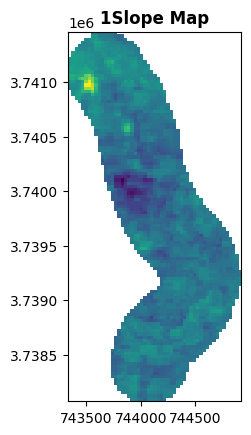

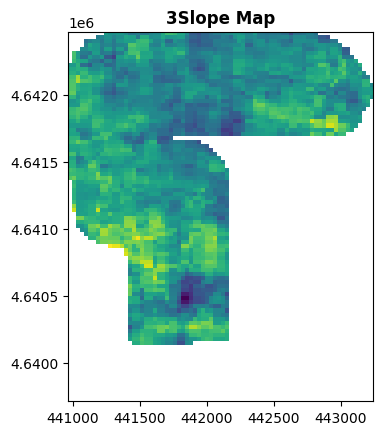

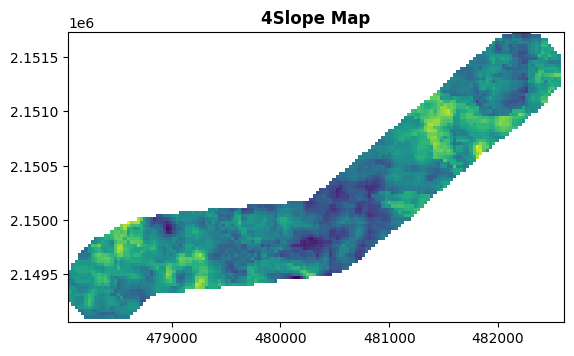

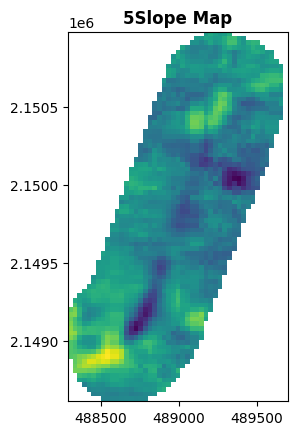

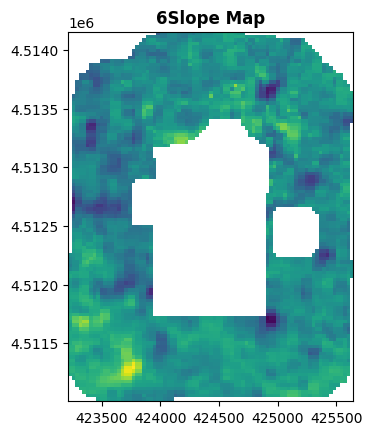

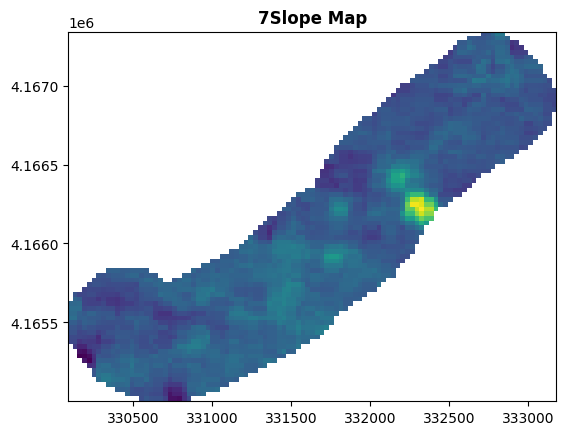

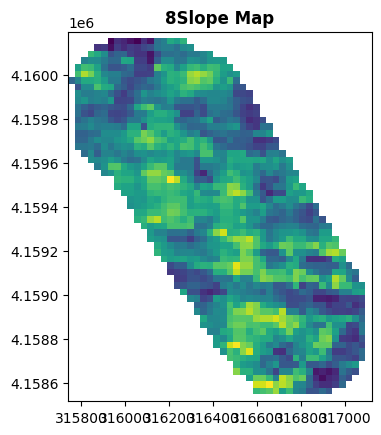

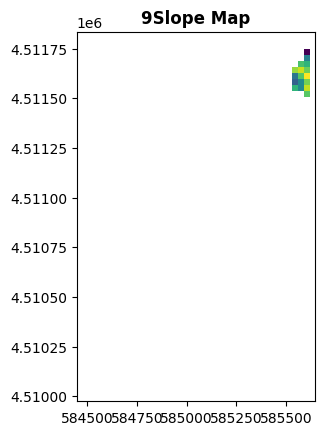

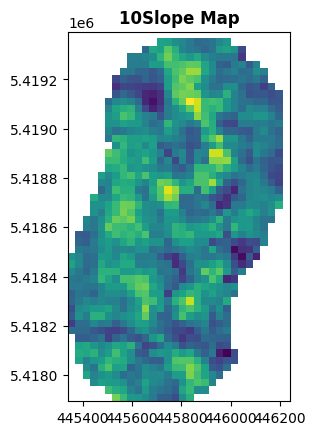

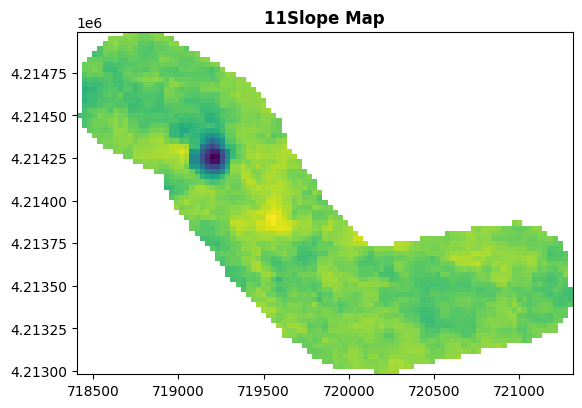

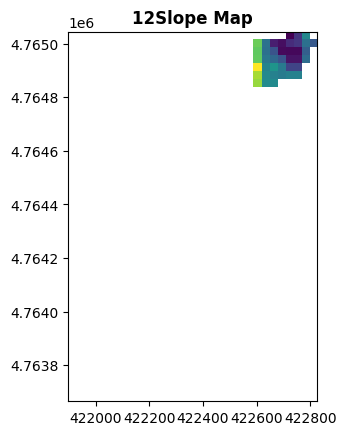

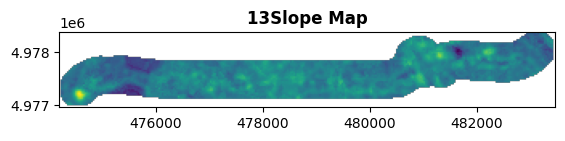

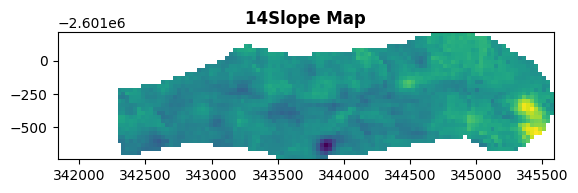

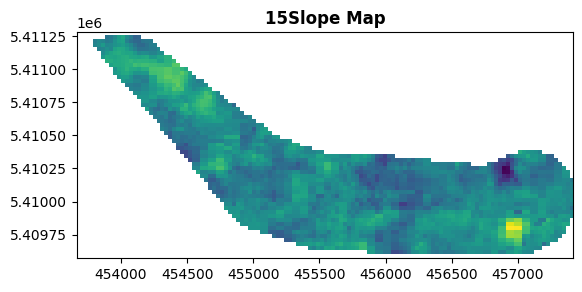

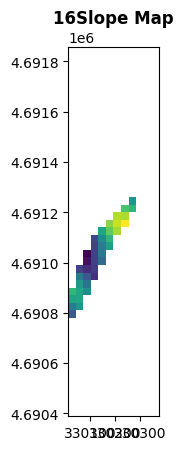

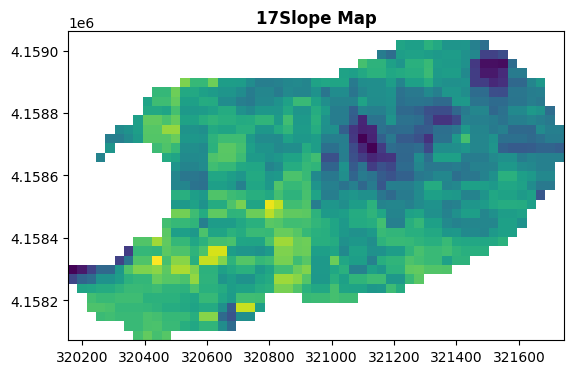

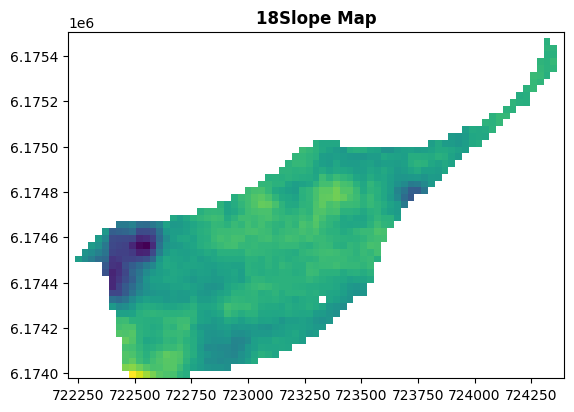

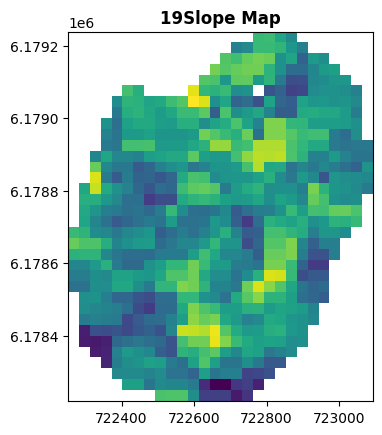

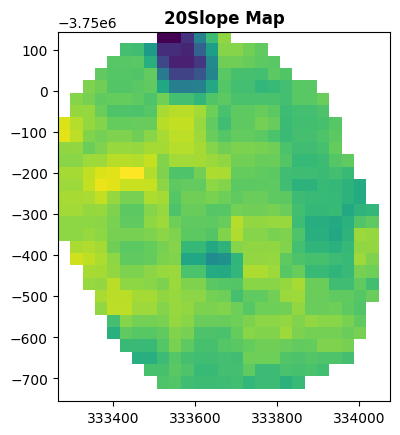

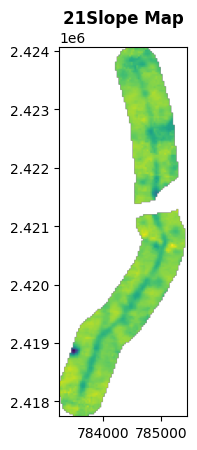

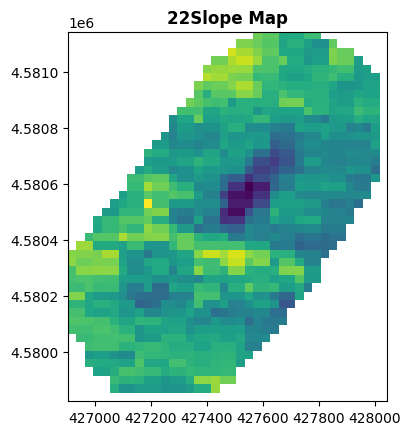

In [80]:
from rasterio.plot import show

# Open the saved file and show it
for id in processed_data_dfs.keys():
    with rasterio.open("/content/tifs/" + id + "_slope.tif") as src:
        show(src, title=id + "Slope Map")
        plt.show()

# Download

In [ ]:
!zip -r met_csvs.zip met_csvs

  adding: met_csvs/ (stored 0%)
  adding: met_csvs/2_met.csv (deflated 90%)
  adding: met_csvs/19_met.csv (deflated 91%)
  adding: met_csvs/7_met.csv (deflated 92%)
  adding: met_csvs/8_met.csv (deflated 92%)
  adding: met_csvs/3_met.csv (deflated 90%)
  adding: met_csvs/11_met.csv (deflated 90%)
  adding: met_csvs/4_met.csv (deflated 91%)
  adding: met_csvs/18_met.csv (deflated 92%)
  adding: met_csvs/14_met.csv (deflated 90%)
  adding: met_csvs/17_met.csv (deflated 90%)
  adding: met_csvs/10_met.csv (deflated 90%)
  adding: met_csvs/5_met.csv (deflated 91%)
  adding: met_csvs/20_met.csv (deflated 91%)
  adding: met_csvs/9_met.csv (deflated 92%)
  adding: met_csvs/.ipynb_checkpoints/ (stored 0%)
  adding: met_csvs/6_met.csv (deflated 90%)
  adding: met_csvs/0_met.csv (deflated 92%)
  adding: met_csvs/21_met.csv (deflated 91%)
  adding: met_csvs/13_met.csv (deflated 90%)
  adding: met_csvs/16_met.csv (deflated 90%)
  adding: met_csvs/12_met.csv (deflated 90%)
  adding: met_csvs/1_met.c

In [ ]:
files.download("met_csvs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>